In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

# Load data
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [ ]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [ ]:
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'seed': 42
}
model = xgb.train(params, dtrain, num_boost_round=100)

In [ ]:
dval = xgb.DMatrix(X_test, label=y_test)
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1000,
    evals=[(dval, 'validation')],
    early_stopping_rounds=10,
    verbose_eval=50
)

[0]	validation-rmse:0.93842
[50]	validation-rmse:0.48511
[100]	validation-rmse:0.47195
[144]	validation-rmse:0.46979


<Axes: >

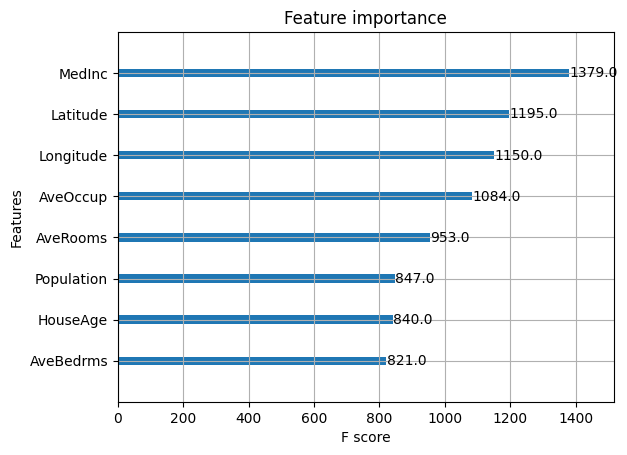

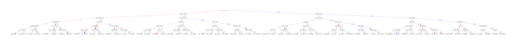

In [ ]:
xgb.plot_importance(model)
xgb.plot_tree(model, num_trees=0)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

preds = model.predict(dtest)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")

RMSE: 0.4697, R²: 0.8316


In [ ]:
model.save_model("xgb_california_model.json")
model_loaded = xgb.Booster()
model_loaded.load_model("xgb_california_model.json")

In [ ]:
params = {
    'objective': 'reg:squarederror',
    'monotone_constraints': "(0,0,1,0,0,0,0,0)"
}


In [ ]:
def custom_rmse(preds, dtrain):
    labels = dtrain.get_label()
    return 'custom_rmse', np.sqrt(((preds - labels)**2).mean())

model = xgb.train(params, dtrain, num_boost_round=100, feval=custom_rmse)

/usr/local/lib/python3.11/dist-packages/xgboost/training.py:38: UserWarning: `feval` is deprecated, use `custom_metric` instead.  They have different behavior when custom objective is also used.See https://xgboost.readthedocs.io/en/latest/tutorials/custom_metric_obj.html for details on the `custom_metric`.
  warnings.warn(


In [ ]:
leaf_indices = model.predict(dtest, pred_leaf=True)
print(leaf_indices[:5])

[[ 78.  75.  76.  78.  78.  74.  82.  86.  67.  61. 119.  74.  94. 113.
   79.  60.  84.  72.  67.  95.  66.  94. 103.  72.  84.  74.  81.  79.
  114.  67.  69.  69.  84.  81.  77.  59.  96.  86.  70.  61. 111.  71.
   80. 101.  71.  56.  78.  94.  67.  64.  67.  65.  74.  70.  95.  70.
   66.  63.  68.  81.  70.  74.  90. 111.  60.  62. 118.  72.  90.  82.
   68.  63.  75. 115.  75.  98.  54.  79.  65.  92.  62.  84.  84.  74.
   63.  77.  95.  77.  85.  93.  68.  60.  66.  77.  81.  79.  72.  65.
   69.  90.]
 [ 78.  66.  88.  78.  92.  72.  70.  66.  88.  62. 119.  72.  94. 113.
   79.  60.  84.  73.  67.  95.  65.  65. 104.  72.  84.  74.  82.  90.
  105.  65.  69.  70.  84.  86.  77.  59. 116.  85.  73.  61. 111.  71.
   90.  69.  71.  56.  78.  94.  67.  64.  67.  67.  74.  70.  95.  83.
   66.  78.  70.  82.  70.  74.  90. 112.  60.  62. 118.  70.  90.  82.
   68.  64.  82. 115.  75. 104.  56.  79.  65. 113.  62.  85.  84.  74.
   81.  77.  95.  77.  85.  93.  66.  60.  77.  77.